In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from transformers import CLIPProcessor, CLIPModel
import umap
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import pandas as pd
from PIL import Image
import computing
import data
from data import CIFAKEDataSet
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

/home/kuniko/anaconda3/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-05-13 08:31:39.179765: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-13 08:31:39.188156: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-13 08:31:39.197881: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDN

In [2]:
root = "../../dataset/CIFAKE/"
filepath = f'{root}test.csv'
df_test = pd.read_csv(filepath)
save_filepath = f'{root}test_hsv.csv'

In [3]:
id_to_class = data.get_id_to_class()

In [4]:
entropies = []
for _, row in df_test.iterrows():
    entropy = computing.get_hsv_entropies(row['filepath'])
    entropies.append(entropy)

In [5]:
entropy_array = np.array(entropies)
df_test['H entropy'] = entropy_array[:, 0]
df_test['S entropy'] = entropy_array[:, 1]
df_test['V entropy'] = entropy_array[:, 2]

In [13]:
entropies = []
for _, row in df_test.iterrows():
    entropy = computing.get_ycbcr_entropies(row['filepath'])
    entropies.append(entropy)

entropy_array = np.array(entropies)
df_test['Y entropy'] = entropy_array[:, 0]
df_test['Cb entropy'] = entropy_array[:, 1]
df_test['Cr entropy'] = entropy_array[:, 2]

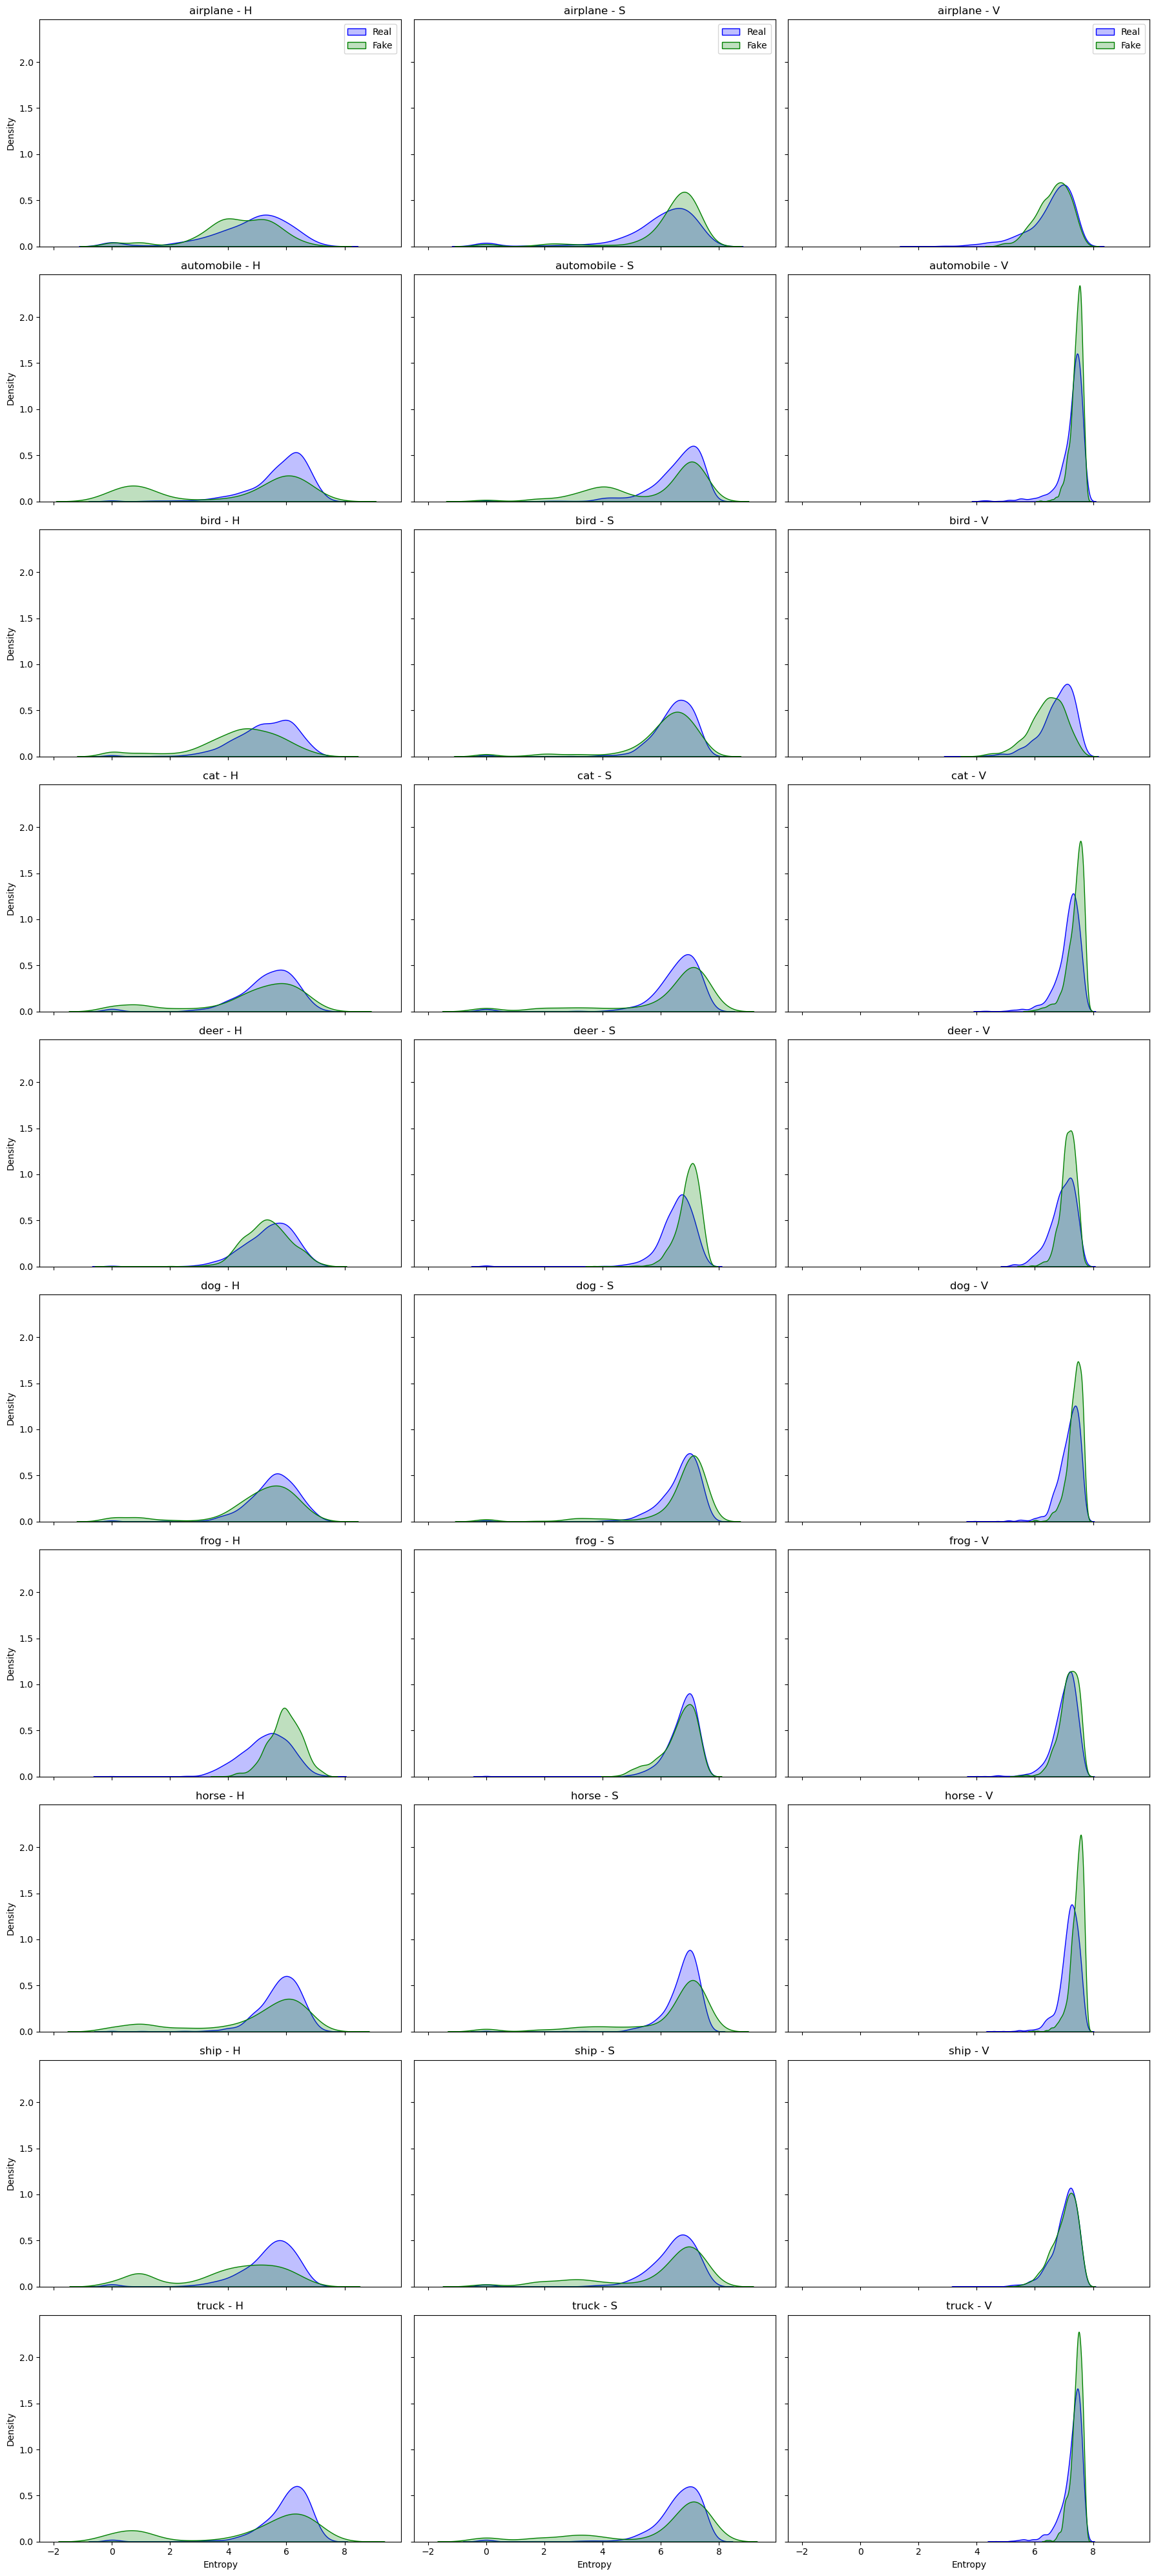

In [7]:
num_classes = len(id_to_class)
fig, axes = plt.subplots(num_classes, 3, figsize=(18, 4 * num_classes), sharex=True, sharey=True)
entropy_channels = ['H entropy', 'S entropy', 'V entropy']
channel_names = ['H', 'S', 'V']

for class_id in range(num_classes):
    df_class = df_test[df_test['label'] == class_id]
    
    for i, (channel, name) in enumerate(zip(entropy_channels, channel_names)):
        ax = axes[class_id, i]
        # Real (blue)
        sns.kdeplot(data=df_class[df_class['real'] == 1], x=channel, ax=ax, fill=True, color='blue', label='Real')
        # Fake (green)
        sns.kdeplot(data=df_class[df_class['real'] == 0], x=channel, ax=ax, fill=True, color='green', label='Fake')

        ax.set_title(f'{id_to_class[class_id]} - {name}')
        ax.set_xlabel('Entropy')
        ax.set_ylabel('Density')

        # 凡例は上の行にだけ表示する（必要なら調整）
        if class_id == 0:
            ax.legend()

plt.tight_layout()
plt.show()

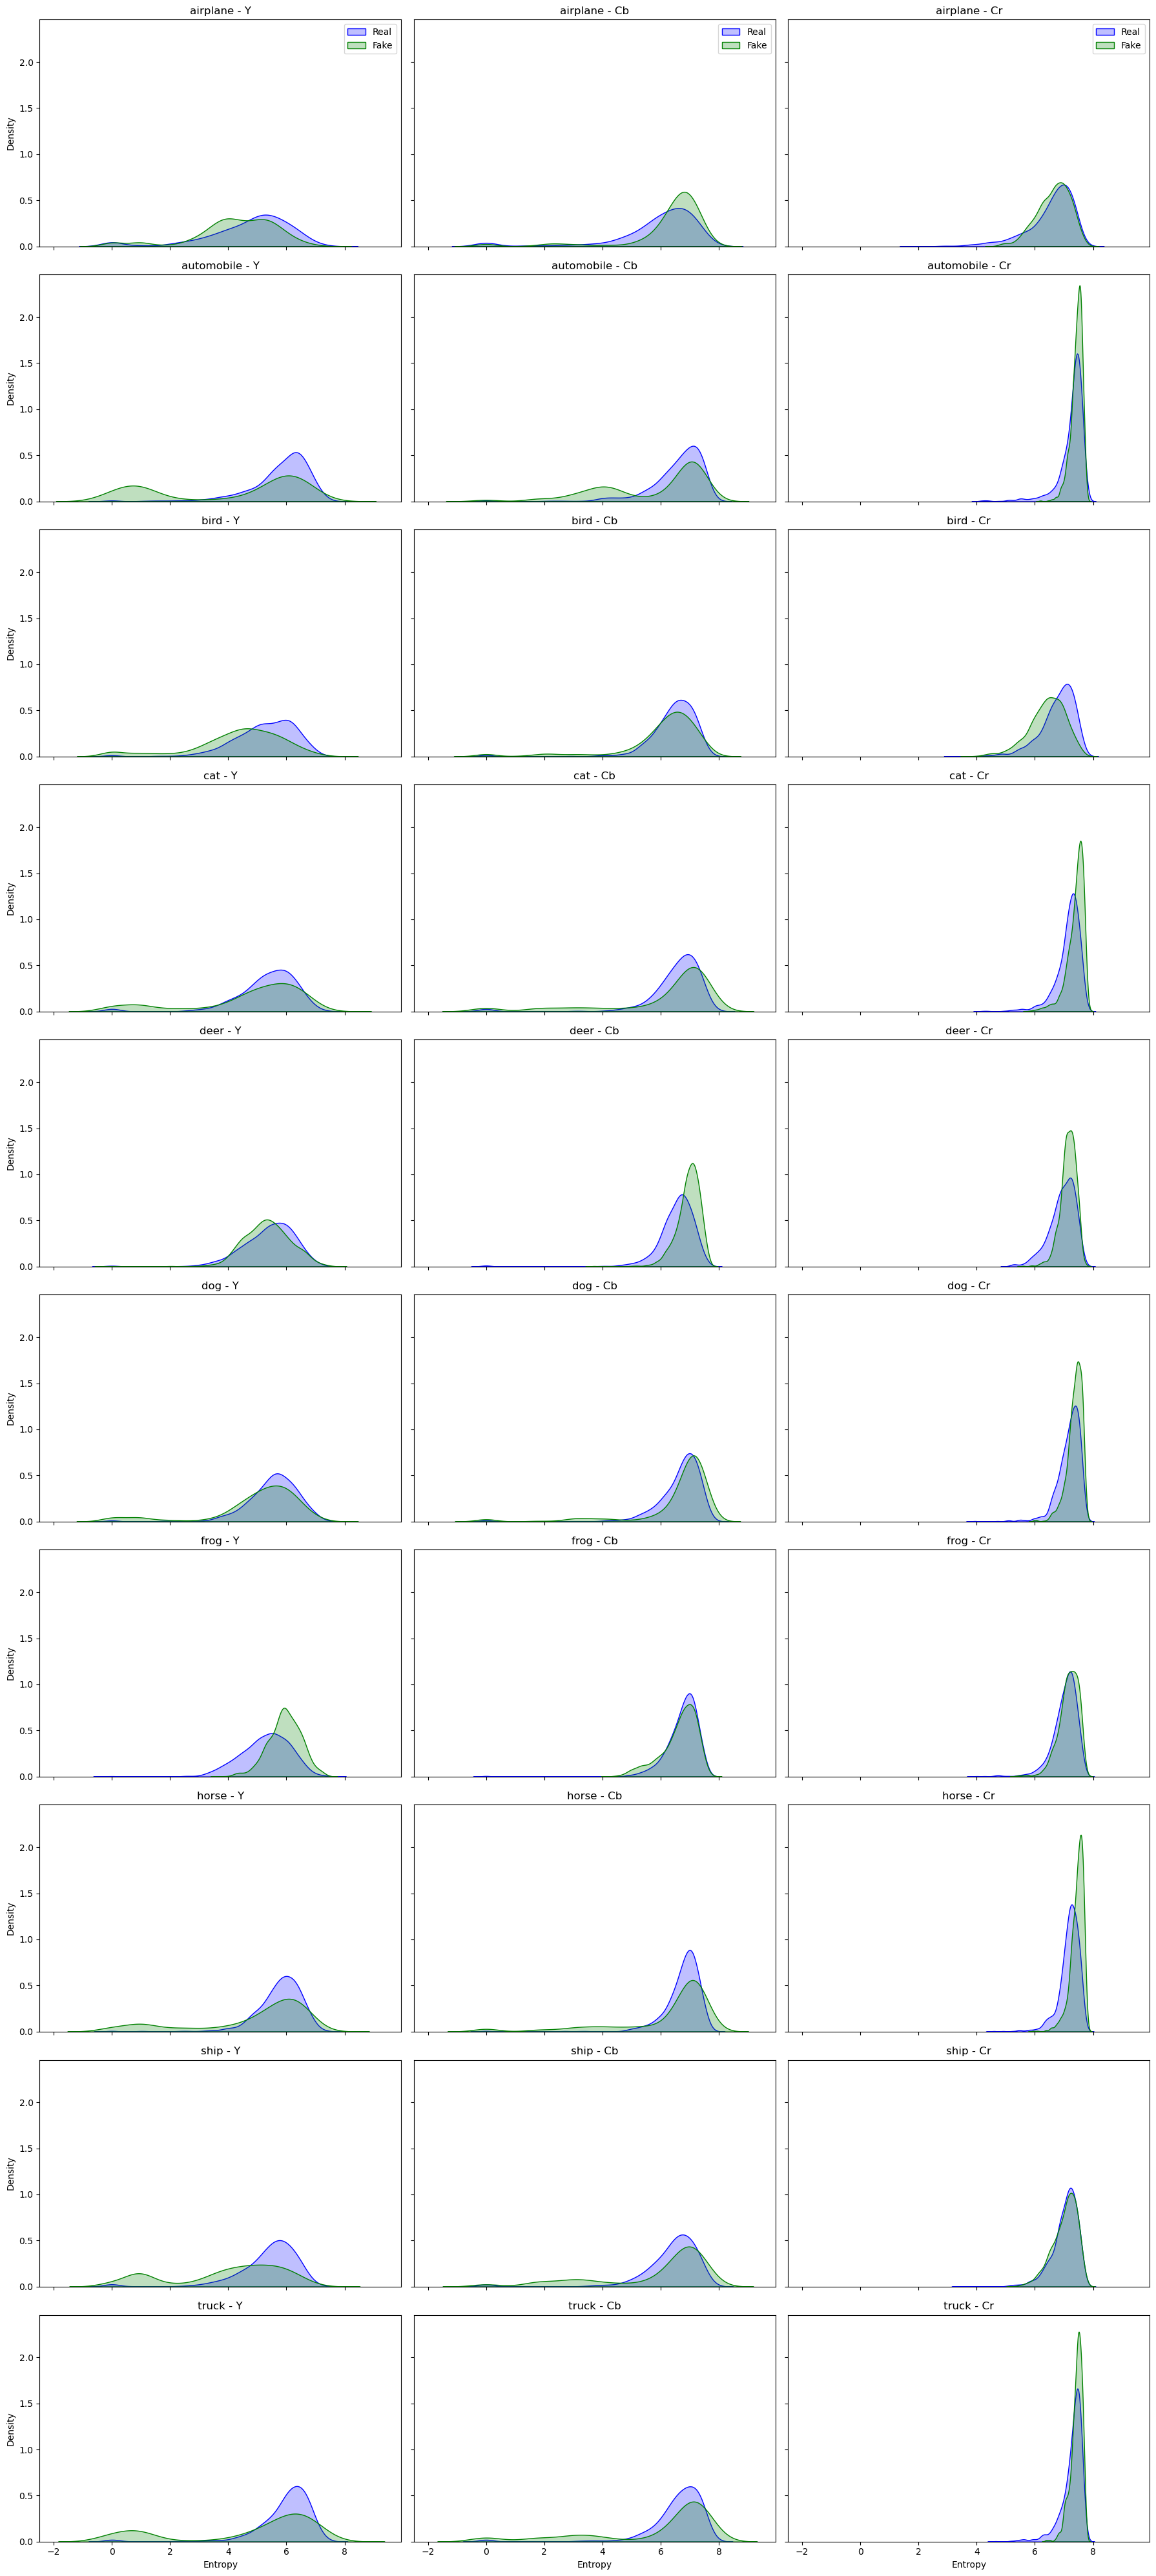

In [14]:
num_classes = len(id_to_class)
fig, axes = plt.subplots(num_classes, 3, figsize=(18, 4 * num_classes), sharex=True, sharey=True)
entropy_channels = ['H entropy', 'S entropy', 'V entropy']
channel_names = ['Y', 'Cb', 'Cr']

for class_id in range(num_classes):
    df_class = df_test[df_test['label'] == class_id]
    
    for i, (channel, name) in enumerate(zip(entropy_channels, channel_names)):
        ax = axes[class_id, i]
        # Real (blue)
        sns.kdeplot(data=df_class[df_class['real'] == 1], x=channel, ax=ax, fill=True, color='blue', label='Real')
        # Fake (green)
        sns.kdeplot(data=df_class[df_class['real'] == 0], x=channel, ax=ax, fill=True, color='green', label='Fake')

        ax.set_title(f'{id_to_class[class_id]} - {name}')
        ax.set_xlabel('Entropy')
        ax.set_ylabel('Density')

        # 凡例は上の行にだけ表示する（必要なら調整）
        if class_id == 0:
            ax.legend()

plt.tight_layout()
plt.show()

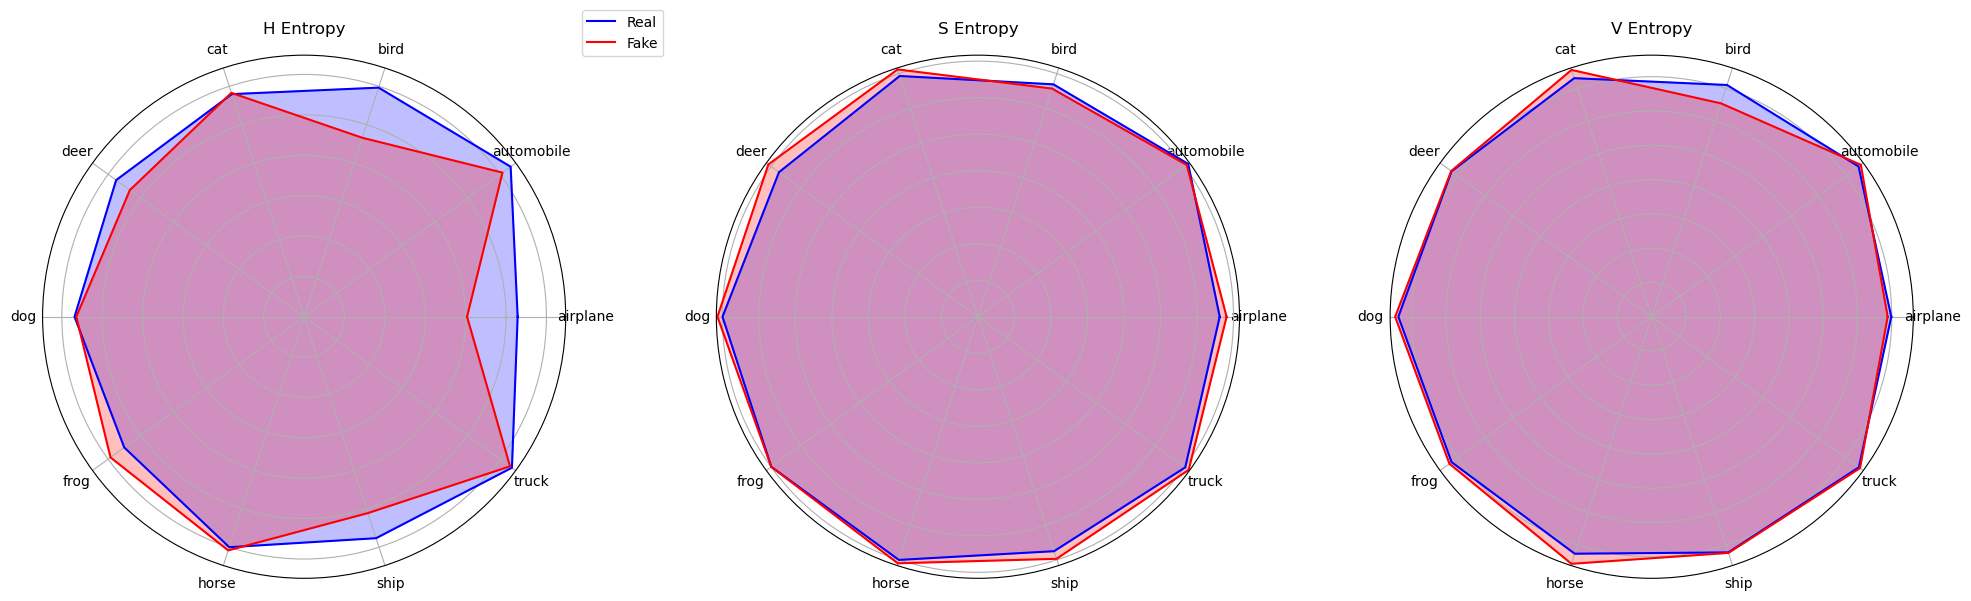

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

entropy_channels = ['H entropy', 'S entropy', 'V entropy']
channel_names = ['H', 'S', 'V']
num_classes = len(id_to_class)

# クラス名のラベル取得
class_labels = [id_to_class[i] for i in range(num_classes)]

# 角度設定（10クラス分 + 最初に戻ってループを閉じる）
angles = np.linspace(0, 2 * np.pi, num_classes, endpoint=False).tolist()
angles += angles[:1]

# Real/Fakeごとのクラス別ピーク値を格納する辞書
real_peaks_dict = {ch: [] for ch in entropy_channels}
fake_peaks_dict = {ch: [] for ch in entropy_channels}

# 各クラスごとにピーク値を取得
for class_id in range(num_classes):
    df_class = df_test[df_test['label'] == class_id]
    
    for ch in entropy_channels:
        # Real
        real_vals = df_class[df_class['real'] == 1][ch].dropna()
        if len(real_vals) > 1:
            kde = gaussian_kde(real_vals)
            x = np.linspace(real_vals.min(), real_vals.max(), 1000)
            y = kde(x)
            real_peaks_dict[ch].append(x[np.argmax(y)])
        else:
            real_peaks_dict[ch].append(0)

        # Fake
        fake_vals = df_class[df_class['real'] == 0][ch].dropna()
        if len(fake_vals) > 1:
            kde = gaussian_kde(fake_vals)
            x = np.linspace(fake_vals.min(), fake_vals.max(), 1000)
            y = kde(x)
            fake_peaks_dict[ch].append(x[np.argmax(y)])
        else:
            fake_peaks_dict[ch].append(0)

# 最後に最初の値を追加（ループを閉じる）
for ch in entropy_channels:
    real_peaks_dict[ch] += real_peaks_dict[ch][:1]
    fake_peaks_dict[ch] += fake_peaks_dict[ch][:1]

# レーダーチャート描画
fig, axes = plt.subplots(1, 3, figsize=(20, 6), subplot_kw=dict(polar=True))

for i, ch in enumerate(entropy_channels):
    ax = axes[i]
    ax.plot(angles, real_peaks_dict[ch], color='blue', label='Real')
    ax.fill(angles, real_peaks_dict[ch], alpha=0.25, color='blue')

    ax.plot(angles, fake_peaks_dict[ch], color='red', label='Fake')
    ax.fill(angles, fake_peaks_dict[ch], alpha=0.25, color='red')

    ax.set_title(f'{channel_names[i]} Entropy')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(class_labels, rotation=45)
    ax.set_yticklabels([])

    if i == 0:
        ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
save_filepath = f'{root}figures/hsv_entropy.png'
plt.savefig(save_filepath)
plt.show()

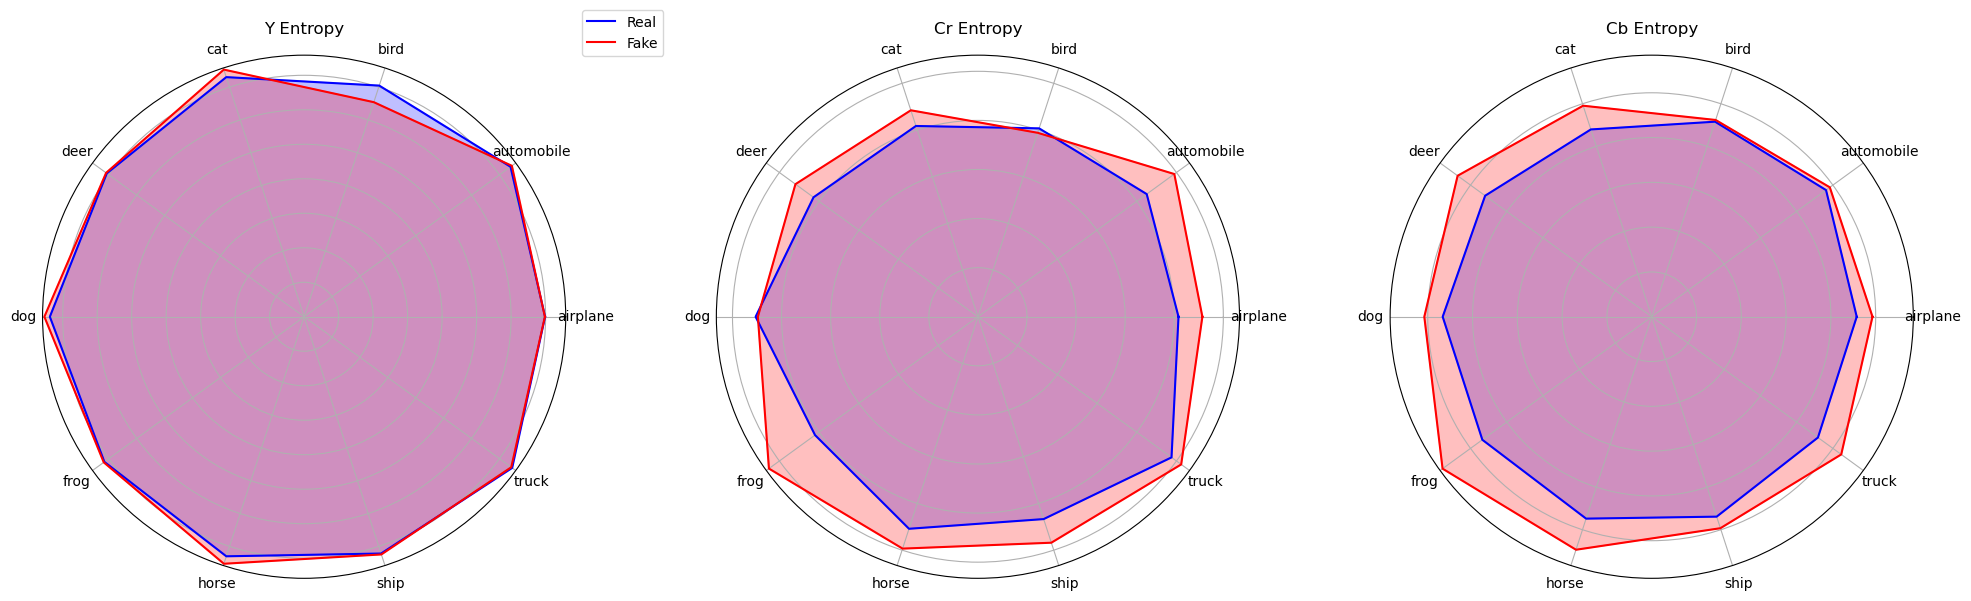

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

entropy_channels = ['Y entropy', 'Cr entropy', 'Cb entropy']
channel_names = ['Y', 'Cr', 'Cb']
num_classes = len(id_to_class)

# クラス名のラベル取得
class_labels = [id_to_class[i] for i in range(num_classes)]

# 角度設定（10クラス分 + 最初に戻ってループを閉じる）
angles = np.linspace(0, 2 * np.pi, num_classes, endpoint=False).tolist()
angles += angles[:1]

# Real/Fakeごとのクラス別ピーク値を格納する辞書
real_peaks_dict = {ch: [] for ch in entropy_channels}
fake_peaks_dict = {ch: [] for ch in entropy_channels}

# 各クラスごとにピーク値を取得
for class_id in range(num_classes):
    df_class = df_test[df_test['label'] == class_id]
    
    for ch in entropy_channels:
        # Real
        real_vals = df_class[df_class['real'] == 1][ch].dropna()
        if len(real_vals) > 1:
            kde = gaussian_kde(real_vals)
            x = np.linspace(real_vals.min(), real_vals.max(), 1000)
            y = kde(x)
            real_peaks_dict[ch].append(x[np.argmax(y)])
        else:
            real_peaks_dict[ch].append(0)

        # Fake
        fake_vals = df_class[df_class['real'] == 0][ch].dropna()
        if len(fake_vals) > 1:
            kde = gaussian_kde(fake_vals)
            x = np.linspace(fake_vals.min(), fake_vals.max(), 1000)
            y = kde(x)
            fake_peaks_dict[ch].append(x[np.argmax(y)])
        else:
            fake_peaks_dict[ch].append(0)

# 最後に最初の値を追加（ループを閉じる）
for ch in entropy_channels:
    real_peaks_dict[ch] += real_peaks_dict[ch][:1]
    fake_peaks_dict[ch] += fake_peaks_dict[ch][:1]

# レーダーチャート描画
fig, axes = plt.subplots(1, 3, figsize=(20, 6), subplot_kw=dict(polar=True))

for i, ch in enumerate(entropy_channels):
    ax = axes[i]
    ax.plot(angles, real_peaks_dict[ch], color='blue', label='Real')
    ax.fill(angles, real_peaks_dict[ch], alpha=0.25, color='blue')

    ax.plot(angles, fake_peaks_dict[ch], color='red', label='Fake')
    ax.fill(angles, fake_peaks_dict[ch], alpha=0.25, color='red')

    ax.set_title(f'{channel_names[i]} Entropy')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(class_labels, rotation=45)
    ax.set_yticklabels([])

    if i == 0:
        ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))

plt.tight_layout()
save_filepath = f'{root}figures/ycbcr_entropy.png'
plt.savefig(save_filepath)
plt.show()

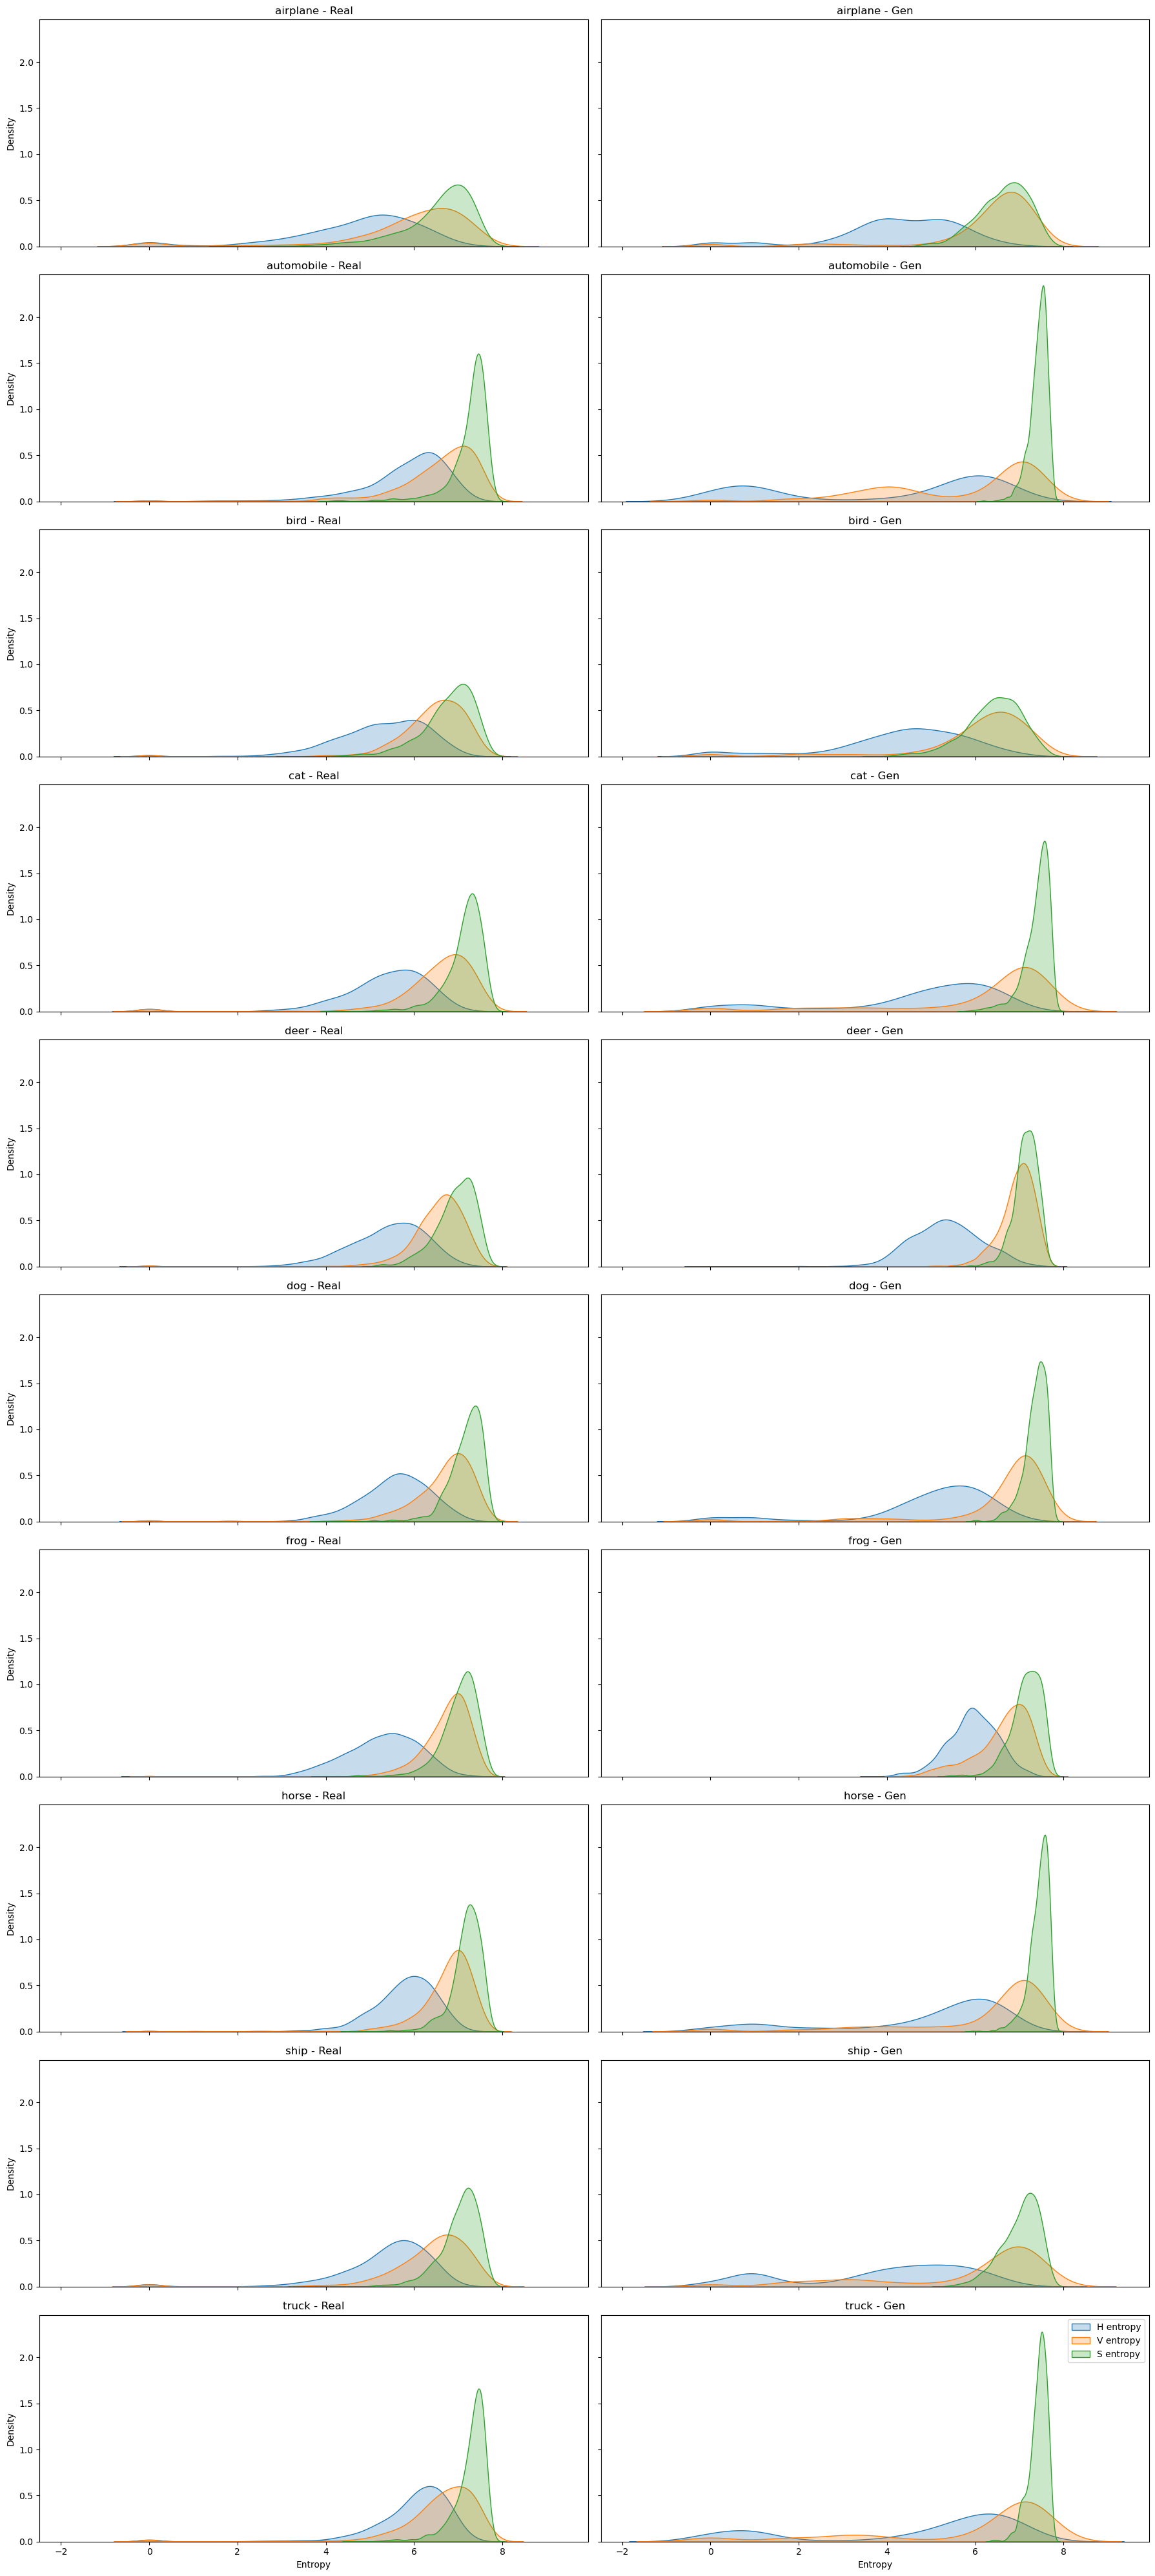

In [16]:
num_classes = len(id_to_class)
fig, axes = plt.subplots(num_classes, 2, figsize=(18, 4 * num_classes), sharex=True, sharey=True)

for class_id in range(num_classes):
    df_class = df_test[df_test['label'] == class_id]

    # Real
    sns.kdeplot(data=df_class[df_class['real'] == 1], x='H entropy', ax=axes[class_id, 0], fill=True, label='H entropy')
    sns.kdeplot(data=df_class[df_class['real'] == 1], x='S entropy', ax=axes[class_id, 0], fill=True, label='V entropy')
    sns.kdeplot(data=df_class[df_class['real'] == 1], x='V entropy', ax=axes[class_id, 0], fill=True, label='S entropy')
    axes[class_id, 0].set_title(f'{id_to_class[class_id]} - Real')

    # Fake
    sns.kdeplot(data=df_class[df_class['real'] == 0], x='H entropy', ax=axes[class_id, 1], fill=True, label='H entropy')
    sns.kdeplot(data=df_class[df_class['real'] == 0], x='S entropy', ax=axes[class_id, 1], fill=True, label='V entropy')
    sns.kdeplot(data=df_class[df_class['real'] == 0], x='V entropy', ax=axes[class_id, 1], fill=True, label='S entropy')
    axes[class_id, 1].set_title(f'{id_to_class[class_id]} - Gen')

for ax_row in axes:
    for ax in ax_row:
        ax.set_xlabel('Entropy')
        ax.set_ylabel('Density')

plt.legend()
plt.tight_layout()
plt.show()